# 05 - Final Simulation and Results!

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# importe the functions to run the full simulations
from tournaments import run_full_tournaments, prepare_tournament_schedule_points
from metrics import get_all_rankings, get_correlations, get_fraction_of_N_players

In [3]:
# importing the parameters stored in the .json file
import json

config_path = "../config/simulation_params.json"

with open(config_path, "r") as f:
    config_params = json.load(f)

In [4]:
# get the tournaments schedule and points 
tournament_points_path = "../config/rules/tournament_properties.txt"
tournament_schedule_path = "../config/rules/tournament_schedule.txt"

## Global correlations and Top N

In [ ]:
# PARAMETERS FOR THE SIMULATIONS

simulation_number = 10
years_per_simulation = 20
warm_up_years = 10 # known from the study of the years needed to stabilise number of ATP points (in previous notebook)

In [6]:
# list for storing all dataframes correlations (one per simulation)
kendall_correlations_full_list = []
weighted_footrule_full_list = []
fraction_of_players_list = []

for simulation in range(1, simulation_number+1):
    print(f"\n -- Simulation n°{simulation} in progress. --")

    # create the calendar (ITF 10 and 20 tournaments put uniformly along the year)
    tournament_schedule_simulation, tournaments_points_simulation = prepare_tournament_schedule_points(tournament_points_path, tournament_schedule_path)

    # 1. launch the simulation
    games_history_simulation, rankings_simulation = run_full_tournaments(years=years_per_simulation,
                                                                         config_params=config_params,
                                                                         tournaments_schedule = tournament_schedule_simulation,
                                                                         tournaments_points = tournaments_points_simulation,
                                                                         seeding=True,
                                                                         random_initial_points=False,
                                                                         track_week_ranks=False)
    
    # 2. calculates the metrics (do not keep the 10 first years for warm-up)
    all_rankings_simulation = get_all_rankings(games_data = games_history_simulation,
                                               rankings = rankings_simulation,
                                               warm_up_years = warm_up_years)
    
    # store the games history / rankings of a year of simulation
    if simulation == 1:
        games_history_simulation_1 = games_history_simulation.copy()
        rankings_history_simulation_1 = rankings_simulation.copy()
        all_rankings_simulation_1 = all_rankings_simulation.copy()
    
    # 3. get the correlations for each year: kendall and weighted footrule
    kendall_correlations_simulation = get_correlations(ranking_metrics_data=all_rankings_simulation, 
                                               warm_up_years=0, 
                                               return_all_years=True,
                                               coefficient = "kendall")
    
    kendall_correlations_simulation["simulation_number"] = simulation # to know which simulation
    kendall_correlations_full_list.append(kendall_correlations_simulation)

    # weighted footrule
    weighted_footrule_correlations_simulation = get_correlations(ranking_metrics_data=all_rankings_simulation, 
                                               warm_up_years=0, 
                                               return_all_years=True,
                                               coefficient = "weighted_footrule")
    
    weighted_footrule_correlations_simulation["simulation_number"] = simulation # to know which simulation
    weighted_footrule_full_list.append(weighted_footrule_correlations_simulation)

    # 4. get the fraction of players in both the ground truth and the metrics for different N
    N = [10, 25, 50, 100, 500]
    fractions_simulation_list = []
    for n in N:
        fraction_of_n_players = get_fraction_of_N_players(ranking_metrics_data=all_rankings_simulation,
                                                          N = n,
                                                          return_all_years = True)
        fraction_of_n_players["n"] = n
        fraction_of_n_players["simulation_number"] = simulation # to know which simulation

        fractions_simulation_list.append(fraction_of_n_players)
    
    fraction_of_players_list.extend(fractions_simulation_list)


 -- Simulation n°1 in progress. --


Initialising the tournament by running a warm-up simulation...
End of the initialisation. Starting the simulation of the tournaments...


  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]


 -- Simulation n°2 in progress. --
Initialising the tournament by running a warm-up simulation...
End of the initialisation. Starting the simulation of the tournaments...


...

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]


 -- Simulation n°10 in progress. --
Initialising the tournament by running a warm-up simulation...
End of the initialisation. Starting the simulation of the tournaments...


  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

In [7]:
# merging all DF together
kendall_correlations_full_data = pd.concat(kendall_correlations_full_list, ignore_index=True)
weighted_footrule_correlations_full_data = pd.concat(weighted_footrule_full_list, ignore_index=True)
fraction_of_players_data = pd.concat(fraction_of_players_list, ignore_index=True)

# transform data for plotting them
kendall_final_data = pd.melt(kendall_correlations_full_data,
                             id_vars=["year", "simulation_number"],
                             var_name="Metrics",
                             value_name="Kendall Coefficient")

weighted_footrule_final_data = pd.melt(weighted_footrule_correlations_full_data,
                                       id_vars=["year", "simulation_number"],
                                       var_name="Metrics",
                                       value_name="Weighted Footrule")

fraction_of_players_final_data = pd.melt(fraction_of_players_data,
                                         id_vars=["year", "simulation_number", "n"],
                                         var_name="Metrics",
                                         value_name="Fraction")

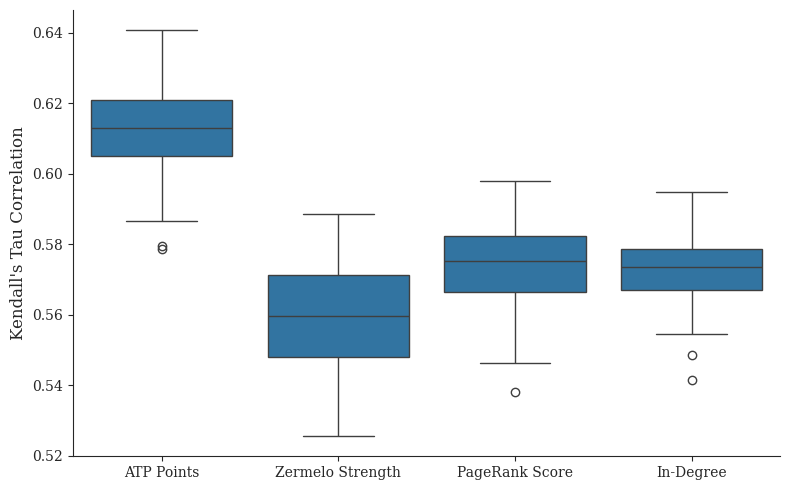

In [8]:
# plot of the results
plt.figure(figsize=(8, 5))
sns.set_style("ticks") 
plt.rcParams.update({'font.family': 'serif'})

sns.boxplot(data=kendall_final_data, x="Metrics", y="Kendall Coefficient",
            order = ["ATP_points", "zermelo_strength", "pagerank_score", "in_degree"])

plt.xlabel(r"", fontsize=12)
plt.ylabel("Kendall's Tau Correlation", fontsize=12)

plt.xticks([0,1,2,3], ["ATP Points", "Zermelo Strength", "PageRank Score", "In-Degree"])

sns.despine()
plt.tight_layout()
plt.show()

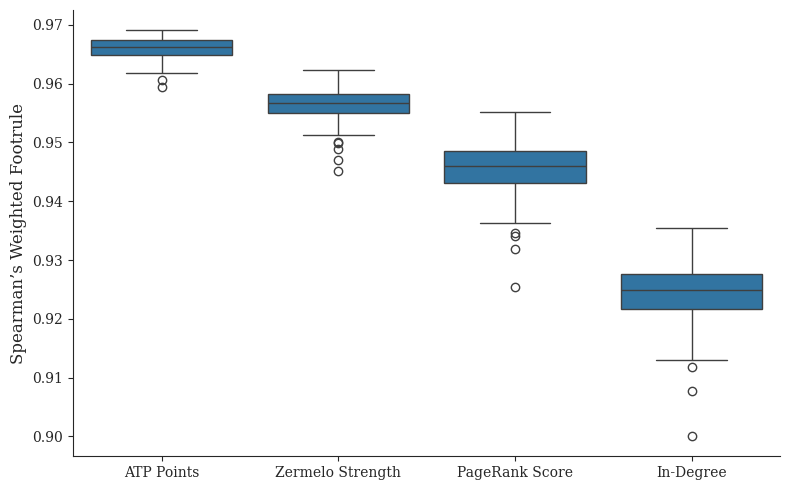

In [9]:
# plot of the results
plt.figure(figsize=(8, 5))
sns.set_style("ticks") 
plt.rcParams.update({'font.family': 'serif'})

sns.boxplot(data=weighted_footrule_final_data, x="Metrics", y="Weighted Footrule",
            order = ["ATP_points", "zermelo_strength", "pagerank_score", "in_degree"])

plt.xlabel(r"", fontsize=12)
plt.ylabel("Spearman’s Weighted Footrule", fontsize=12)

plt.xticks([0,1,2,3], ["ATP Points", "Zermelo Strength", "PageRank Score", "In-Degree"])

sns.despine()
plt.tight_layout()
plt.show()


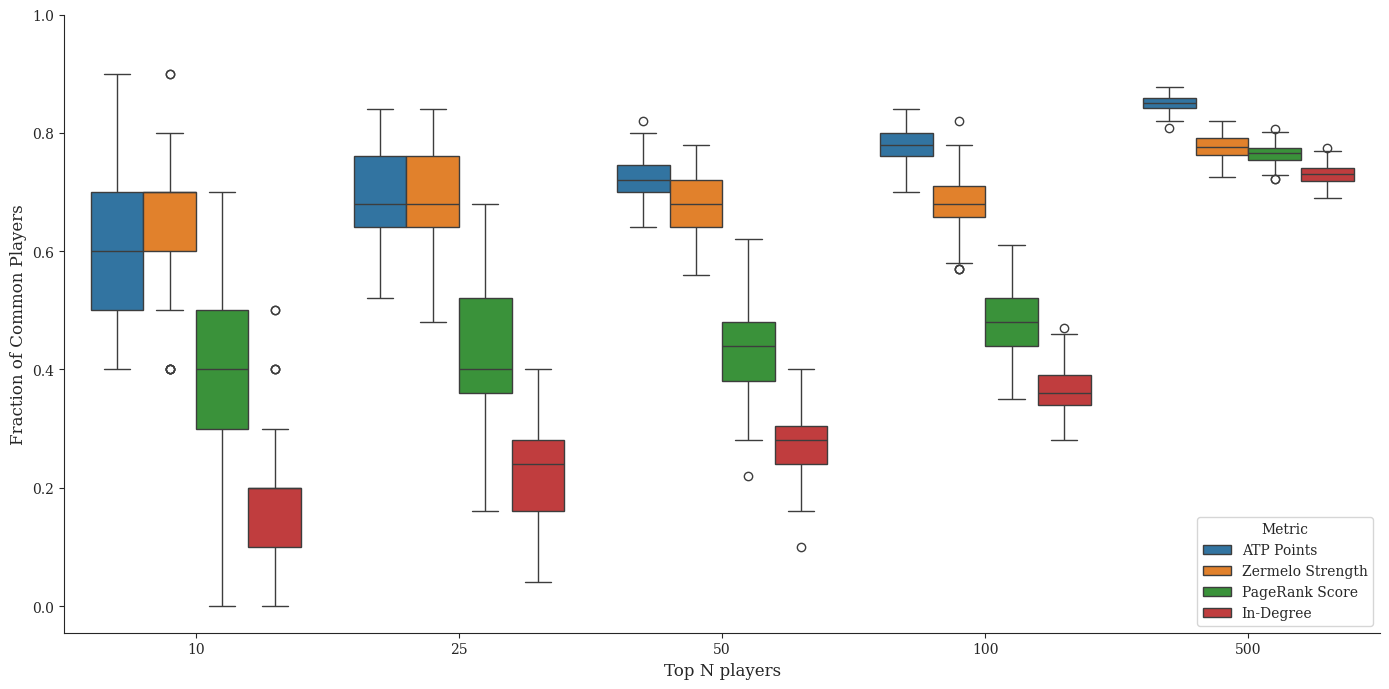

In [10]:
plt.figure(figsize=(14, 7))
sns.set_style("ticks") 
plt.rcParams.update({'font.family': 'serif'})

sns.boxplot(data=fraction_of_players_final_data, x="n", y="Fraction", hue="Metrics",
            hue_order=["ATP_points", "zermelo_strength", "pagerank_score", "in_degree"])

plt.xlabel("Top N players", fontsize=12)
plt.ylabel("Fraction of Common Players", fontsize=12)

handles, labels = plt.gca().get_legend_handles_labels()
new_labels = ["ATP Points", "Zermelo Strength", "PageRank Score", "In-Degree"]
plt.legend(handles, new_labels, title="Metric", loc="lower right")
plt.yticks(np.arange(0,1.1,0.2))

sns.despine()
plt.tight_layout()
plt.show()

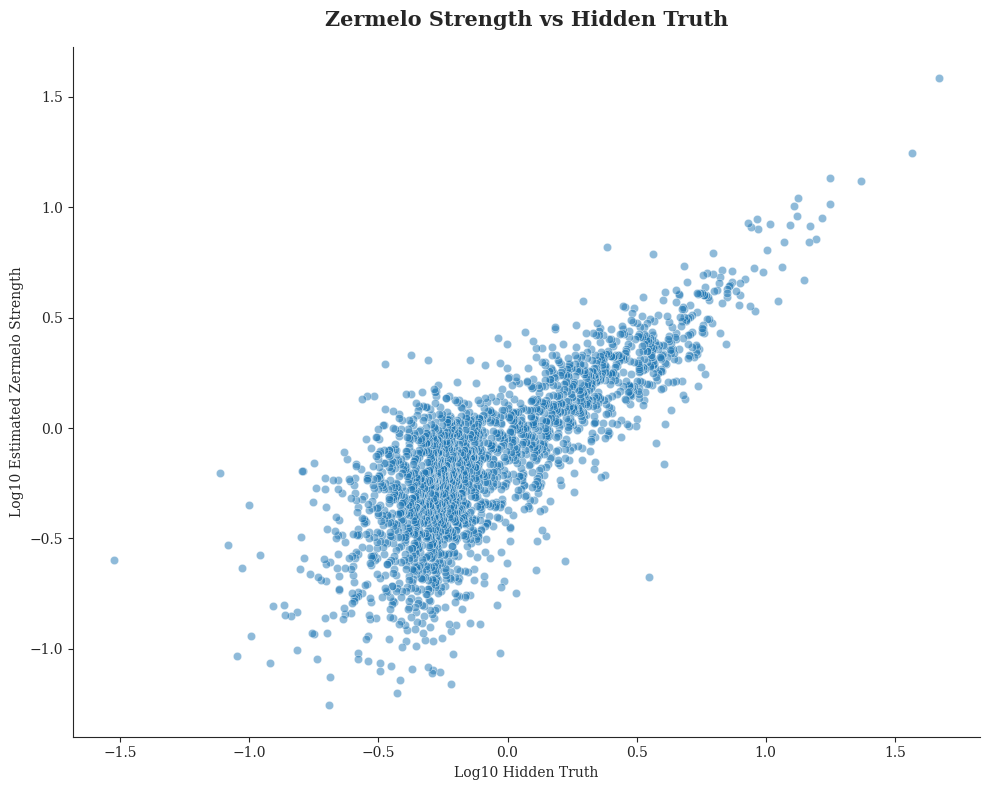

In [11]:
# plot of zermelo strength vs hidden truth (both in log10)
chosen_year_1 = 19

plot_zermelo_vs_truth_data = all_rankings_simulation_1[all_rankings_simulation_1["year"]==chosen_year_1].copy()
plot_zermelo_vs_truth_data = plot_zermelo_vs_truth_data.dropna(subset=["zermelo_strength"])

# get the log10 for the estimated strength so that we can compare them
plot_zermelo_vs_truth_data["log10_zermelo_strength"] = np.log10(plot_zermelo_vs_truth_data["zermelo_strength"])

# graph

plt.figure(figsize=(10,8))
sns.set_style("ticks") 
plt.rcParams.update({'font.family': 'serif'})

sns.scatterplot(data=plot_zermelo_vs_truth_data, x="log10_hidden_truth", y="log10_zermelo_strength", alpha=0.5)


plt.title("Zermelo Strength vs Hidden Truth", fontweight="bold", pad=15, fontsize=15)
plt.xlabel("Log10 Hidden Truth")
plt.ylabel("Log10 Estimated Zermelo Strength")

sns.despine()
plt.tight_layout()
plt.show()


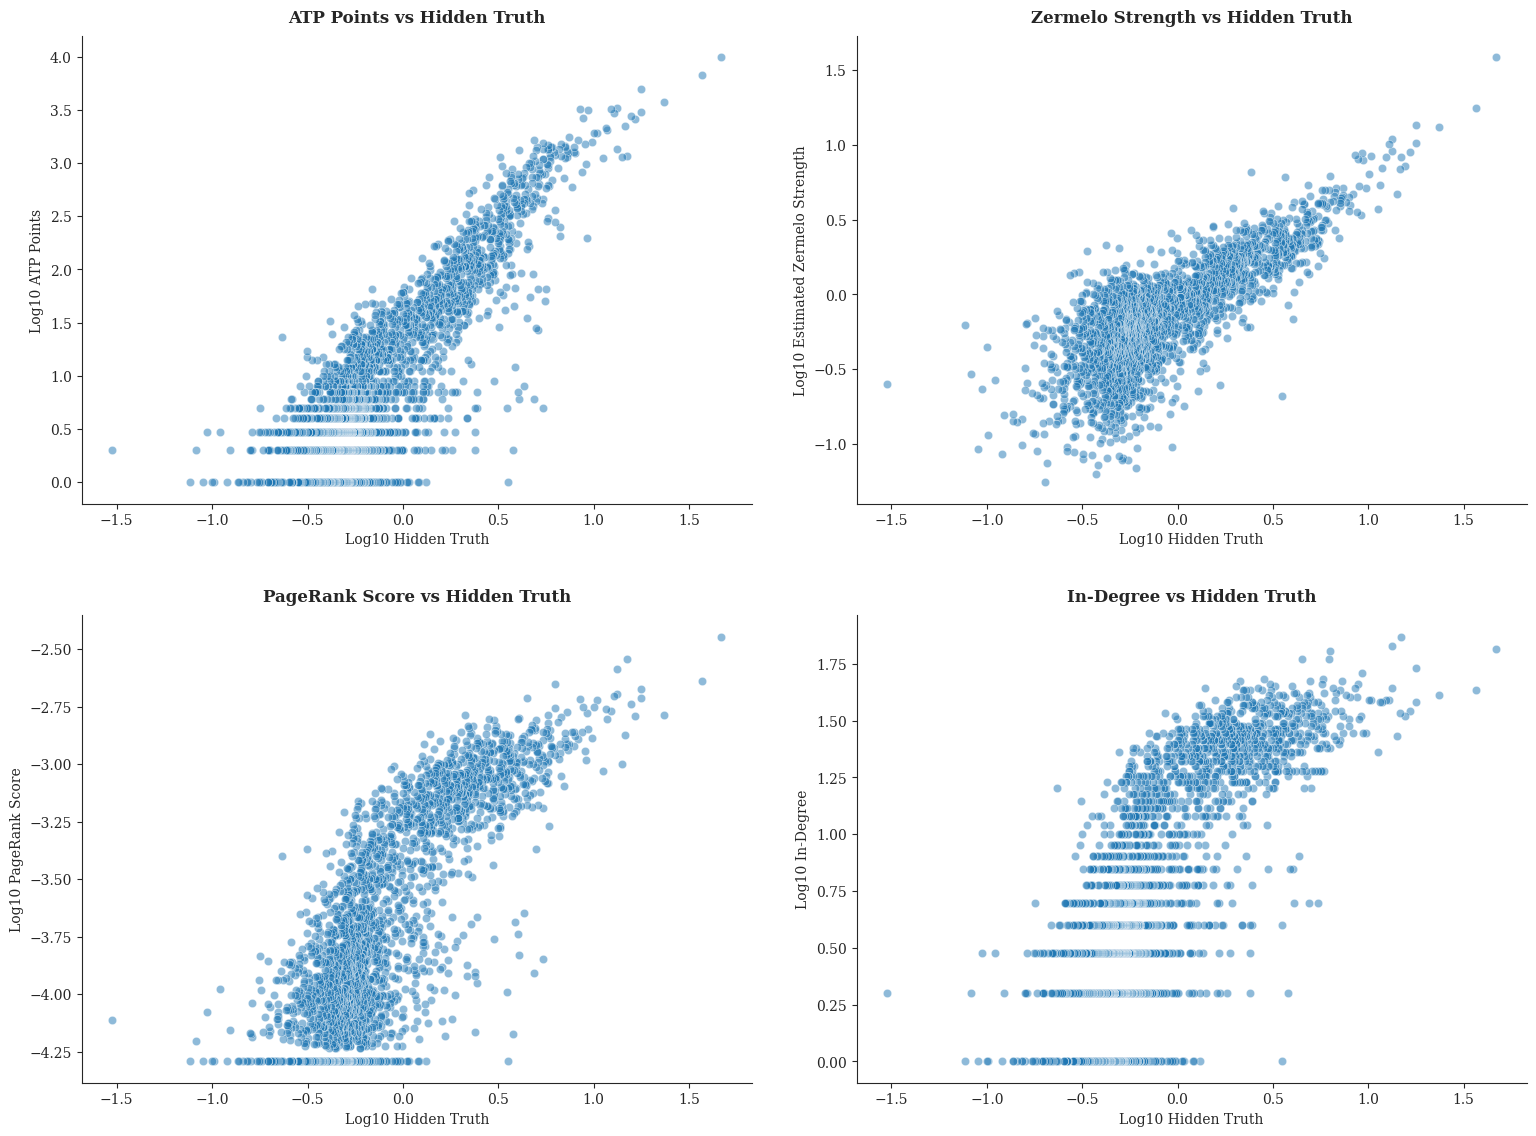

In [12]:
# do a full graph with all metrics
plot_zermelo_vs_truth_data["log10_ATP_points"] = np.log10(plot_zermelo_vs_truth_data["ATP_points"]+1)
plot_zermelo_vs_truth_data["log10_in_degree"] = np.log10(plot_zermelo_vs_truth_data["in_degree"]+1)
plot_zermelo_vs_truth_data["log10_pagerank_score"] = np.log10(plot_zermelo_vs_truth_data["pagerank_score"])

plt.figure(figsize=(16, 12))
sns.set_style("ticks") 
plt.rcParams.update({'font.family': 'serif'})

# ATP points
plt.subplot(2, 2, 1)
sns.scatterplot(data=plot_zermelo_vs_truth_data, x="log10_hidden_truth", y="log10_ATP_points", alpha=0.5)
plt.title("ATP Points vs Hidden Truth", fontweight="bold", pad=10)
plt.xlabel("Log10 Hidden Truth")
plt.ylabel("Log10 ATP Points")

# Zermelo strength
plt.subplot(2, 2, 2)
sns.scatterplot(data=plot_zermelo_vs_truth_data, x="log10_hidden_truth", y="log10_zermelo_strength", alpha=0.5) 
plt.title("Zermelo Strength vs Hidden Truth", fontweight="bold", pad=10)
plt.xlabel("Log10 Hidden Truth")
plt.ylabel("Log10 Estimated Zermelo Strength")

# PageRank Score
plt.subplot(2, 2, 3)
sns.scatterplot(data=plot_zermelo_vs_truth_data, x="log10_hidden_truth", y="log10_pagerank_score", alpha=0.5) 
plt.title("PageRank Score vs Hidden Truth", fontweight="bold", pad=10)
plt.xlabel("Log10 Hidden Truth")
plt.ylabel("Log10 PageRank Score")

# In-Degree 
plt.subplot(2, 2, 4)
sns.scatterplot(data=plot_zermelo_vs_truth_data, x="log10_hidden_truth", y="log10_in_degree", alpha=0.5)
plt.title("In-Degree vs Hidden Truth", fontweight="bold", pad=10)
plt.xlabel("Log10 Hidden Truth")
plt.ylabel("Log10 In-Degree")

sns.despine()
plt.tight_layout(pad=3.0)
plt.show()

## Effect of Seeding on Top Players

In [13]:
seeding_effect_results = []
top_10_errors_results = []

for simulation in range(1, simulation_number+1):
    print(f"\n -- Simulation n°{simulation} in progress. --")

    # create the calendar (ITF 10 and 20 tournaments put uniformly along the year)
    tournament_schedule_simulation, tournaments_points_simulation = prepare_tournament_schedule_points(tournament_points_path, tournament_schedule_path)

    # 1st option:: WITH seeding
    games_history_seeding, rankings_seeding = run_full_tournaments(years=years_per_simulation,
                                                                         config_params=config_params,
                                                                         tournaments_schedule = tournament_schedule_simulation,
                                                                         tournaments_points = tournaments_points_simulation,
                                                                         seeding=True,
                                                                         random_initial_points=False,
                                                                         track_week_ranks=False)
    
    all_rankings_seeding = get_all_rankings(games_history_seeding, rankings_seeding, warm_up_years = warm_up_years)
    
    # 2nd option: WITHOUT seeding
    games_history_no_seeding, rankings_no_seeding = run_full_tournaments(years=years_per_simulation,
                                                                         config_params=config_params,
                                                                         tournaments_schedule = tournament_schedule_simulation,
                                                                         tournaments_points = tournaments_points_simulation,
                                                                         seeding=False, # changing parameter
                                                                         random_initial_points=False,
                                                                         track_week_ranks=False)
    
    all_rankings_no_seeding = get_all_rankings(games_history_no_seeding, rankings_no_seeding, warm_up_years = warm_up_years)


    valid_years = sorted(all_rankings_seeding["year"].unique()) # get the valid years (same for seeding and no seeding)

    for year in valid_years:
       
        # get the games for each year
        games_seeding_year = games_history_seeding[games_history_seeding["year"]==year]
        games_no_seeding_year = games_history_no_seeding[games_history_no_seeding["year"]==year]
        # get the all rankings for each year
        all_rankings_seeding_year = all_rankings_seeding[all_rankings_seeding["year"]==year].dropna(subset=["zermelo_strength"])
        all_rankings_no_seeding_year = all_rankings_no_seeding[all_rankings_no_seeding["year"]==year].dropna(subset=["zermelo_strength"])

        # get the number of different semi-finalists
        seeding_final_games = games_seeding_year[(games_seeding_year["round"]=="SF") & (games_seeding_year["tournament_level"].isin([1000,2000]))]
        no_seeding_final_games = games_no_seeding_year[(games_no_seeding_year["round"]=="SF") & (games_no_seeding_year["tournament_level"].isin([1000,2000]))]

        seeding_finalists = set(seeding_final_games["winner_id"]).union(set(seeding_final_games["loser_id"]))
        no_seeding_finalists = set(no_seeding_final_games["winner_id"]).union(set(no_seeding_final_games["loser_id"]))

        seeding_number_finalists = len(seeding_finalists)
        no_seeding_number_finalists = len(no_seeding_finalists)


        # get the total number of ATP points
        seeding_total_ATP_points = np.sum(all_rankings_seeding_year["ATP_points"])
        no_seeding_total_ATP_points = np.sum(all_rankings_no_seeding_year["ATP_points"])

        N = [10, 25, 50, 100, 500]

        seeding_ratio_top_n_list = []
        no_seeding_ratio_top_n_list = []

        for n in N:

            # compare the real ranking differences
            if n==10:
                all_rankings_seeding_year["rank_hidden_truth"] = all_rankings_seeding_year["log10_hidden_truth"].rank(ascending=False, method="min")
                all_rankings_seeding_year["rank_ATP"] = all_rankings_seeding_year["ATP_points"].rank(ascending=False, method="min")
                all_rankings_seeding_year["rank_zermelo"] = all_rankings_seeding_year["zermelo_strength"].rank(ascending=False, method="min")

                all_rankings_no_seeding_year["rank_hidden_truth"] = all_rankings_no_seeding_year["log10_hidden_truth"].rank(ascending=False, method="min")
                all_rankings_no_seeding_year["rank_ATP"] = all_rankings_no_seeding_year["ATP_points"].rank(ascending=False, method="min")
                all_rankings_no_seeding_year["rank_zermelo"] = all_rankings_no_seeding_year["zermelo_strength"].rank(ascending=False, method="min")

                # get the lines of rankings only for the Top 10 from the hidden truth
                true_top_10_seeding = all_rankings_seeding_year.nsmallest(10, "rank_hidden_truth")
                true_top_10_no_seeding = all_rankings_no_seeding_year.nsmallest(10, "rank_hidden_truth")

            
                # calculates the mean absolute error of rankings for the Top 10 real mean compared to the rankings of zermelo and ATP
                ATP_errors_seeding = abs(true_top_10_seeding["rank_hidden_truth"]-true_top_10_seeding["rank_ATP"]).mean()
                ATP_errors_no_seeding = abs(true_top_10_no_seeding["rank_hidden_truth"]-true_top_10_no_seeding["rank_ATP"]).mean()
            
                zermelo_errors_seeding = abs(true_top_10_seeding["rank_hidden_truth"]-true_top_10_seeding["rank_zermelo"]).mean()
                zermelo_errors_no_seeding = abs(true_top_10_no_seeding["rank_hidden_truth"]-true_top_10_no_seeding["rank_zermelo"]).mean()

                # save the results (4 dictionaries: 2 metrics and seeding/no seeding)
                top_10_errors_results.append({
                    "simulation_number": simulation,
                    "n": n,
                    "year": year,
                    "seeding": "with seeding",
                    "metric": "ATP_points",
                    "mean_rank_error": ATP_errors_seeding 
                })

                top_10_errors_results.append({
                    "simulation_number": simulation,
                    "n": n,
                    "year": year,
                    "seeding": "with seeding",
                    "metric": "zermelo_strength",
                    "mean_rank_error": zermelo_errors_seeding 
                })

                top_10_errors_results.append({
                    "simulation_number": simulation,
                    "n": n,
                    "year": year,
                    "seeding": "no seeding",
                    "metric": "ATP_points",
                    "mean_rank_error": ATP_errors_no_seeding 
                })

                top_10_errors_results.append({
                    "simulation_number": simulation,
                    "n": n,
                    "year": year,
                    "seeding": "no seeding",
                    "metric": "zermelo_strength",
                    "mean_rank_error": zermelo_errors_no_seeding 
                })

            # get the fraction of points got by the top N players 
            seeding_top_n_points = np.sum(all_rankings_seeding_year.nlargest(n, "ATP_points", keep="first")["ATP_points"])
            no_seeding_top_n_points = np.sum(all_rankings_no_seeding_year.nlargest(n, "ATP_points", keep="first") ["ATP_points"])

            seeding_ratio = seeding_top_n_points/seeding_total_ATP_points
            no_seeding_ratio = no_seeding_top_n_points / no_seeding_total_ATP_points

            # compare the players in the top N for ATP points and ground truth
            seeding_top_n_players_truth = set(all_rankings_seeding_year.nlargest(n, "log10_hidden_truth", keep="all")["player_id"])
            no_seeding_top_n_players_truth = set(all_rankings_no_seeding_year.nlargest(n, "log10_hidden_truth", keep="all")["player_id"])

            # for each metric get the fraction
            for metric in ["ATP_points", "zermelo_strength", "pagerank_score", "in_degree"]:

                seeding_top_n_players_metric = set(all_rankings_seeding_year.nlargest(n, metric, keep="all")["player_id"])
                no_seeding_top_n_players_metric = set(all_rankings_no_seeding_year.nlargest(n, metric, keep="all")["player_id"])

                seeding_fraction = len(seeding_top_n_players_truth.intersection(seeding_top_n_players_metric)) / n
                no_seeding_fraction = len(no_seeding_top_n_players_truth.intersection(no_seeding_top_n_players_metric)) / n

                # save the results: one line per n, year, simulation and seeding parameter 
                # (finalists_number will be the same for all n)
                seeding_effect_results.append({
                    "simulation_number": simulation,
                    "n": n,
                    "year": year,
                    "seeding": "with seeding",
                    "metric": metric,
                    "semi_finalists_number": seeding_number_finalists,
                    "points_ratio": seeding_ratio,
                    "truth_fraction": seeding_fraction
                    })
                
                seeding_effect_results.append({
                    "simulation_number": simulation,
                    "n": n,
                    "year": year,
                    "seeding": "no seeding",
                    "metric": metric,
                    "semi_finalists_number": no_seeding_number_finalists,
                    "points_ratio": no_seeding_ratio,
                    "truth_fraction": no_seeding_fraction
                    })


 -- Simulation n°1 in progress. --
Initialising the tournament by running a warm-up simulation...
End of the initialisation. Starting the simulation of the tournaments...


  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

Initialising the tournament by running a warm-up simulation...
End of the initialisation. Starting the simulation of the tournaments...


  0%|          | 0/20 [00:00<?, ?it/s]

...

  0%|          | 0/10 [00:00<?, ?it/s]


 -- Simulation n°3 in progress. --
Initialising the tournament by running a warm-up simulation...
End of the initialisation. Starting the simulation of the tournaments...


  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
seeding_effects_data = pd.DataFrame(seeding_effect_results)
top_10_errors_data = pd.DataFrame(top_10_errors_results)

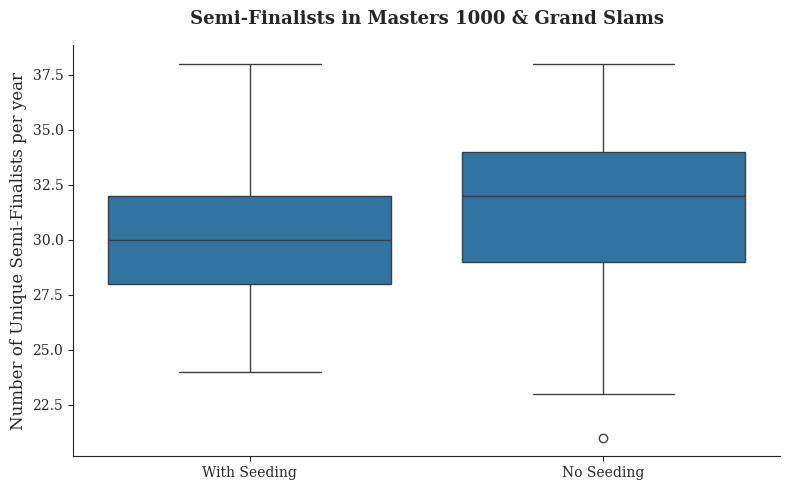

In [ ]:
# graph 1: check the difference in terms of semi-finalists for ATP1000 and ATP2000 tournaments

# getting the data by removing the lines containing the same results (n has no influence on the semi finalists number)
semi_finalists_data = seeding_effects_data[["simulation_number", "year", "seeding", "semi_finalists_number"]].drop_duplicates()

plt.figure(figsize=(8, 5))
sns.set_style("ticks") 
plt.rcParams.update({'font.family': 'serif'})

sns.boxplot(data=semi_finalists_data, x="seeding", y="semi_finalists_number")

plt.xlabel("", fontsize=12)
plt.ylabel("Number of Unique Semi-Finalists per year", fontsize=12)
plt.title("Semi-Finalists in Masters 1000 & Grand Slams", fontsize=13, fontweight="bold", pad=15)
plt.xticks([0, 1], ["With Seeding", "No Seeding"])

sns.despine()
plt.tight_layout()
plt.show()


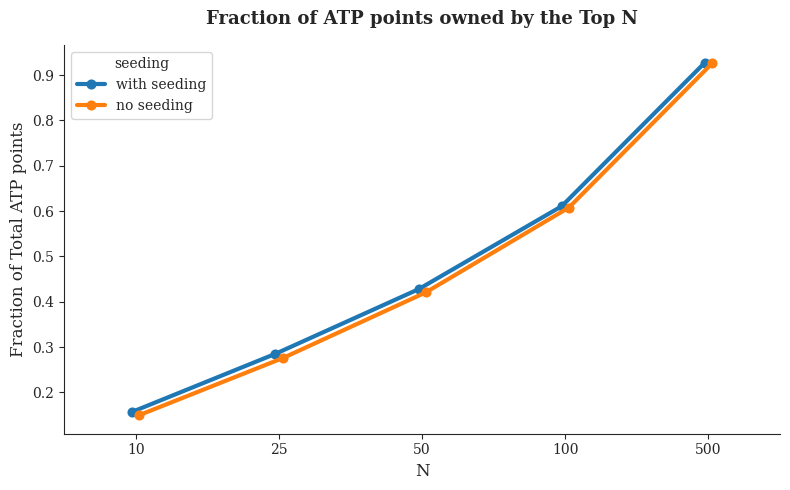

In [ ]:
# see whether the number of ATP points for the top N players change or not

seeding_fraction_points_data = seeding_effects_data[seeding_effects_data["metric"]=="ATP_points"]

plt.figure(figsize=(8, 5))
sns.set_style("ticks") 
plt.rcParams.update({'font.family': 'serif'})

sns.pointplot(data=seeding_fraction_points_data, x="n", y="points_ratio", hue="seeding", dodge=True, markersize=5,
              linewidth=3)

plt.xlabel("N", fontsize=12)
plt.ylabel("Fraction of Total ATP points", fontsize=12)
plt.title("Fraction of ATP points owned by the Top N", fontsize=13, fontweight="bold", pad=15)

sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
stats_seeding_fraction_points = seeding_fraction_points_data.groupby(["n", "seeding"])["points_ratio"].agg(["mean", "std"]).reset_index()
stats_seeding_fraction_points

,n,seeding,mean,std
0,10,no seeding,0.149860,0.011064
1,10,with seeding,0.157010,0.010709
2,25,no seeding,0.275395,0.009580
3,25,with seeding,0.285041,0.009672
4,50,no seeding,0.420500,0.006953
5,50,with seeding,0.427617,0.006899
6,100,no seeding,0.607807,0.005123
7,100,with seeding,0.610783,0.004475
8,500,no seeding,0.925919,0.001406
9,500,with seeding,0.927707,0.001358


In [ ]:
for n in N:
    # with seeding
    stats_with_seeding_n = stats_seeding_fraction_points[(stats_seeding_fraction_points["n"]==n) & (stats_seeding_fraction_points["seeding"]=="with seeding")]
    mean_seeding_n = stats_with_seeding_n["mean"].values[0]
    std_seeding_n = stats_with_seeding_n["std"].values[0]

    # without seeding
    stats_with_no_seeding_n = stats_seeding_fraction_points[(stats_seeding_fraction_points["n"]==n) & (stats_seeding_fraction_points["seeding"]=="no seeding")]
    mean_no_seeding_n = stats_with_no_seeding_n["mean"].values[0]
    std_no_seeding_n = stats_with_no_seeding_n["std"].values[0]


    # calculates the % of gain with seeding
    percentage_gain_with_seeding = (mean_seeding_n-mean_no_seeding_n)/mean_no_seeding_n*100

    print(f"\n Top {n} players:")
    print(f"Fraction of ATP points (no seeding): {mean_no_seeding_n:.4f} ± {std_no_seeding_n:.4f}")
    print(f"Fraction of ATP points (with seeding): {mean_seeding_n:.4f} ± {std_seeding_n:.4f}")
    print(f"Relative advantage of Seeding: {percentage_gain_with_seeding:.4f}%")



 Top 10 players:
Fraction of ATP points (no seeding): 0.1499 ± 0.0111
Fraction of ATP points (with seeding): 0.1570 ± 0.0107
Relative advantage of Seeding: 4.7715%

 Top 25 players:
Fraction of ATP points (no seeding): 0.2754 ± 0.0096
Fraction of ATP points (with seeding): 0.2850 ± 0.0097
Relative advantage of Seeding: 3.5028%

 Top 50 players:
Fraction of ATP points (no seeding): 0.4205 ± 0.0070
Fraction of ATP points (with seeding): 0.4276 ± 0.0069
Relative advantage of Seeding: 1.6923%

 Top 100 players:
Fraction of ATP points (no seeding): 0.6078 ± 0.0051
Fraction of ATP points (with seeding): 0.6108 ± 0.0045
Relative advantage of Seeding: 0.4896%

 Top 500 players:
Fraction of ATP points (no seeding): 0.9259 ± 0.0014
Fraction of ATP points (with seeding): 0.9277 ± 0.0014
Relative advantage of Seeding: 0.1930%


In [ ]:
# merge seeding and no seeding together on 1 line
stats_fractions_points_with_seeding = seeding_fraction_points_data[seeding_fraction_points_data["seeding"]=="with seeding"]
stats_fractions_points_no_seeding = seeding_fraction_points_data[seeding_fraction_points_data["seeding"]=="no seeding"]

# suffixes to add at the end of each column
stats_fractions_points_merged = pd.merge(stats_fractions_points_with_seeding, stats_fractions_points_no_seeding, on=["simulation_number", "n", "year"], suffixes=("_with", "_no"))

# get the percentage for each simulation and year and n
stats_fractions_points_merged["seeding_percentage_adv"] = (stats_fractions_points_merged["points_ratio_with"]-stats_fractions_points_merged["points_ratio_no"])/stats_fractions_points_merged["points_ratio_no"]*100

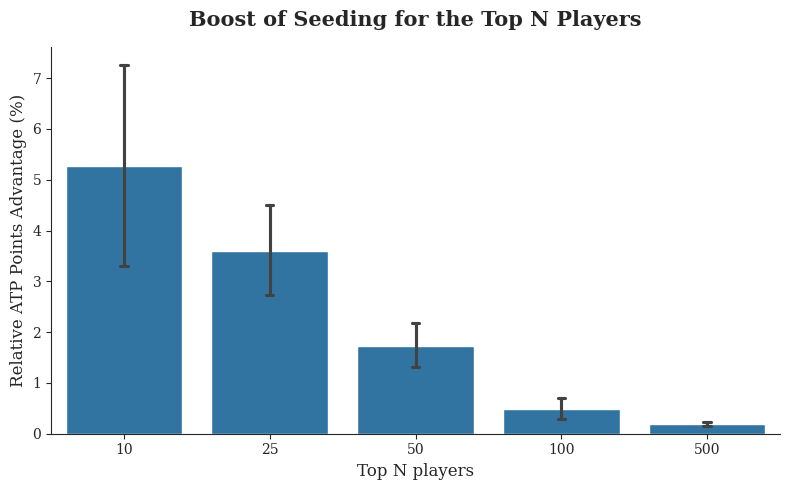

In [ ]:
plt.figure(figsize=(8, 5))
sns.set_style("ticks") 
plt.rcParams.update({'font.family': 'serif'})

sns.barplot(data=stats_fractions_points_merged, x="n", y="seeding_percentage_adv", 
           capsize=0.05)

plt.xlabel("Top N players", fontsize=12)
plt.ylabel("Relative ATP Points Advantage (%)", fontsize=12)
plt.title("Boost of Seeding for the Top N Players", fontsize=15, fontweight="bold", pad=15)

sns.despine()
plt.tight_layout()
plt.show()

In [ ]:
# graph of the truth fraction (ATP points and Zermelo, with or without seeding)
truth_fraction_data = seeding_effects_data[seeding_effects_data["metric"].isin(["ATP_points", "zermelo_strength"])].copy()
truth_fraction_data["seeding"] = truth_fraction_data["seeding"].map({"no seeding": "No Seeding", "with seeding": "With Seeding"})
truth_fraction_data["metric"] = truth_fraction_data["metric"].map({"ATP_points": "ATP Points", "zermelo_strength": "Zermelo Strength"})

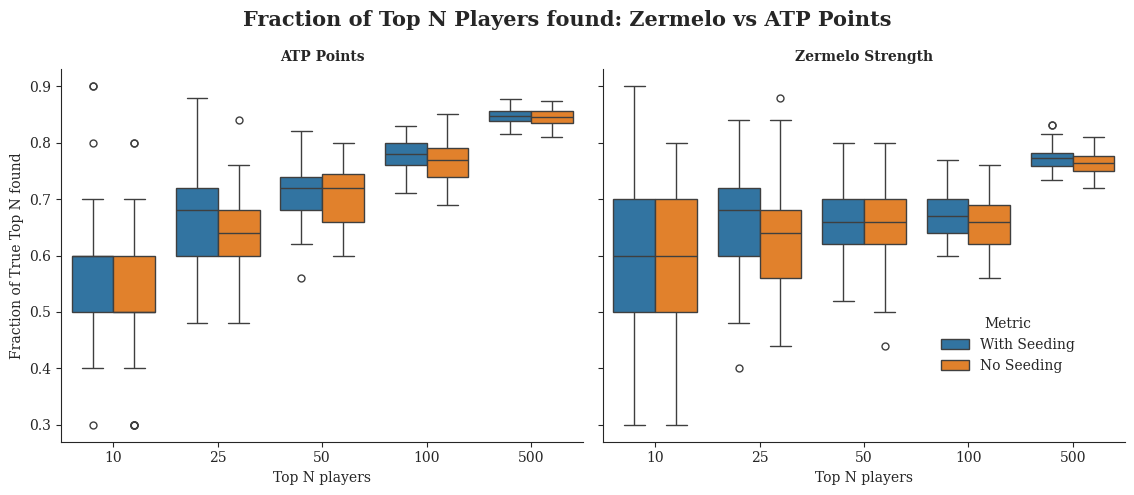

In [ ]:
sns.set_style("ticks") 
plt.rcParams.update({'font.family': 'serif'})

fraction_graph = sns.catplot(data=truth_fraction_data, x="n", y="truth_fraction", hue="seeding", 
                    col="metric", kind="box")


fraction_graph.set_axis_labels("Top N players", "Fraction of True Top N found")
fraction_graph.set_titles("{col_name}", fontweight="bold")
fraction_graph.figure.suptitle("Fraction of Top N Players found: Zermelo vs ATP Points", fontsize=15, fontweight="bold")
fraction_graph.legend.set_title("Metric")
fraction_graph.legend.set_bbox_to_anchor((0.95, 0.3))  

sns.despine()
plt.tight_layout()
plt.show()

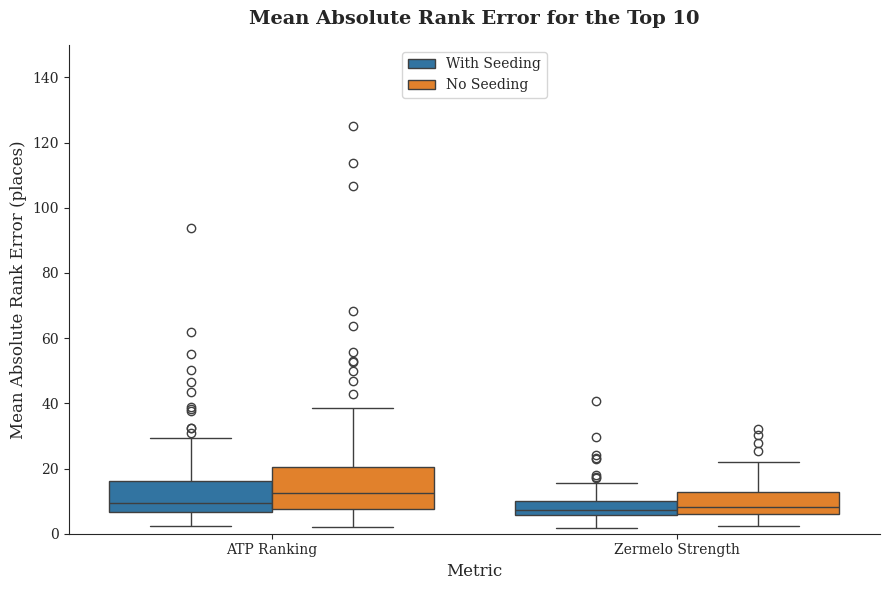

In [ ]:
plt.figure(figsize=(9, 6))
sns.set_style("ticks") 
plt.rcParams.update({'font.family': 'serif'})

sns.boxplot(data=top_10_errors_data, x="metric", y="mean_rank_error", hue="seeding")

plt.xlabel("Metric", fontsize=12)
plt.ylabel("Mean Absolute Rank Error (places)", fontsize=12)
plt.title("Mean Absolute Rank Error for the Top 10", fontsize=14, fontweight="bold", pad=15)


handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ["With Seeding", "No Seeding"], loc="upper center")

plt.xticks([0, 1], ["ATP Ranking", "Zermelo Strength"])

plt.ylim(0,150)
sns.despine()
plt.tight_layout()
plt.show()

## Radicchi-like Plots
(based on _Who is the best player ever? A complex network analysis of the history of professional tennis_)